# 03 Cohort Retention / Repeat Purchase

This notebook defines monthly user cohorts by first valid order month, then calculates month-1 and month-3 repeat purchase rates and renders a cohort heatmap.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

ROOT = Path.cwd()
if not (ROOT / 'sql').exists():
    ROOT = ROOT.parent
DB_PATH = ROOT / 'data' / 'raw' / 'olist.sqlite'
SQL_PATHS = [
    ROOT / 'sql' / 'metrics_v0.sql',
    ROOT / 'sql' / 'cohort.sql',
]
MAX_MONTH = 6

if not DB_PATH.exists():
    raise FileNotFoundError(f'Missing database: {DB_PATH}')

conn = sqlite3.connect(DB_PATH)
required_tables = {'orders', 'customers', 'order_payments', 'order_items'}
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'", conn
)['name']
missing_tables = required_tables - set(tables)
if missing_tables:
    raise RuntimeError(
        'Database is missing required tables: '
        + ', '.join(sorted(missing_tables))
        + '. If you only see an empty placeholder sqlite file, replace it with the real Olist database first.'
    )

for sql_path in SQL_PATHS:
    conn.executescript(sql_path.read_text())

print(f'Connected to: {DB_PATH}')

Matplotlib is building the font cache; this may take a moment.


Connected to: /Users/hanqin/internet_ds_project/data/raw/olist.sqlite


## 1. Cohort Summary

Month 1 and Month 3 repeat rates are calculated against each cohort's first-order users.

In [2]:
summary = pd.read_sql_query(
    '''
    WITH latest AS (
      SELECT MAX(order_month) AS latest_order_month
      FROM v_user_order_months
    )
    SELECT
      s.cohort_month,
      s.cohort_users,
      s.m1_repeat_users,
      s.m1_repeat_rate,
      s.m3_repeat_users,
      s.m3_repeat_rate,
      (
        CAST(strftime('%Y', l.latest_order_month) AS INTEGER) * 12
        + CAST(strftime('%m', l.latest_order_month) AS INTEGER)
      ) - (
        CAST(strftime('%Y', s.cohort_month) AS INTEGER) * 12
        + CAST(strftime('%m', s.cohort_month) AS INTEGER)
      ) AS months_observed
    FROM v_cohort_repeat_summary s
    CROSS JOIN latest l
    ORDER BY s.cohort_month
    ''',
    conn,
)

summary

,cohort_month,cohort_users,m1_repeat_users,m1_repeat_rate,m3_repeat_users,m3_repeat_rate,months_observed
0,2016-09-01,1,0,0.000000,0,0.000000,24
1,2016-10-01,290,0,0.000000,0,0.000000,23
2,2016-12-01,1,1,1.000000,0,0.000000,21
3,2017-01-01,752,3,0.003989,1,0.001330,20
4,2017-02-01,1690,4,0.002367,2,0.001183,19
5,2017-03-01,2571,13,0.005056,10,0.003890,18
6,2017-04-01,2325,14,0.006022,4,0.001720,17
7,2017-05-01,3541,17,0.004801,14,0.003954,16
8,2017-06-01,3102,14,0.004513,12,0.003868,15
9,2017-07-01,3822,20,0.005233,9,0.002355,14


In [3]:
summary_display = summary.copy()
summary_display['cohort_month'] = pd.to_datetime(summary_display['cohort_month'])
summary_display['cohort_month'] = summary_display['cohort_month'].dt.strftime('%Y-%m')

summary_display.style.format({
    'm1_repeat_rate': '{:.1%}',
    'm3_repeat_rate': '{:.1%}',
})

,cohort_month,cohort_users,m1_repeat_users,m1_repeat_rate,m3_repeat_users,m3_repeat_rate,months_observed
0,2016-09,1,0,0.0%,0,0.0%,24
1,2016-10,290,0,0.0%,0,0.0%,23
2,2016-12,1,1,100.0%,0,0.0%,21
3,2017-01,752,3,0.4%,1,0.1%,20
4,2017-02,1690,4,0.2%,2,0.1%,19
5,2017-03,2571,13,0.5%,10,0.4%,18
6,2017-04,2325,14,0.6%,4,0.2%,17
7,2017-05,3541,17,0.5%,14,0.4%,16
8,2017-06,3102,14,0.5%,12,0.4%,15
9,2017-07,3822,20,0.5%,9,0.2%,14


## 2. Cohort Heatmap

Rows are first-order cohorts, columns are months since first order, and values are repeat / retention rates.

In [4]:
retention = pd.read_sql_query(
    f'''
    SELECT
      cohort_month,
      month_number,
      cohort_users,
      active_users,
      retention_rate
    FROM v_cohort_retention
    WHERE month_number BETWEEN 0 AND {MAX_MONTH}
    ORDER BY cohort_month, month_number
    ''',
    conn,
)

heatmap = retention.pivot(index='cohort_month', columns='month_number', values='retention_rate')
heatmap.index = pd.to_datetime(heatmap.index).strftime('%Y-%m')
heatmap.columns = [f'M{month}' for month in heatmap.columns]
heatmap

,M0,M1,M2,M3,M4,M5,M6
cohort_month,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003448
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003989,0.002660,0.001330,0.003989,0.001330,0.003989
2017-02,1.0,0.002367,0.002959,0.001183,0.004142,0.001183,0.002367
2017-03,1.0,0.005056,0.003501,0.003890,0.003501,0.001556,0.001556
2017-04,1.0,0.006022,0.002151,0.001720,0.003011,0.002581,0.003441
2017-05,1.0,0.004801,0.004801,0.003954,0.003106,0.003389,0.004236
2017-06,1.0,0.004513,0.003546,0.003868,0.002579,0.003868,0.003546


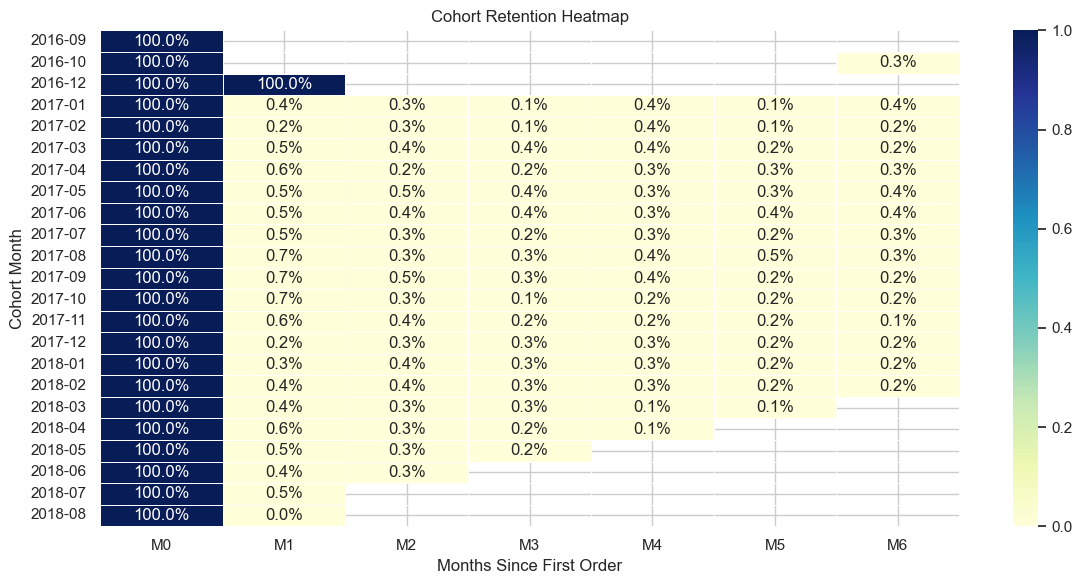

In [5]:
ax = sns.heatmap(
    heatmap,
    annot=True,
    fmt='.1%',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
ax.set_title('Cohort Retention Heatmap')
ax.set_xlabel('Months Since First Order')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.show()

## 3. Auto-generated Conclusion

The cell below highlights the best and weakest cohorts among those with enough observation window.

In [6]:
eligible_m1 = summary[summary['months_observed'] >= 1].copy()
eligible_m3 = summary[summary['months_observed'] >= 3].copy()

if eligible_m1.empty:
    print('No cohort has at least 1 full month of observation yet.')
else:
    best_m1 = eligible_m1.loc[eligible_m1['m1_repeat_rate'].idxmax()]
    worst_m1 = eligible_m1.loc[eligible_m1['m1_repeat_rate'].idxmin()]
    print(
        f"Best M1 cohort: {best_m1['cohort_month'][:7]} | users={int(best_m1['cohort_users'])} | M1 repeat={best_m1['m1_repeat_rate']:.1%}"
    )
    print(
        f"Weakest M1 cohort: {worst_m1['cohort_month'][:7]} | users={int(worst_m1['cohort_users'])} | M1 repeat={worst_m1['m1_repeat_rate']:.1%}"
    )

if eligible_m3.empty:
    print('No cohort has at least 3 full months of observation yet.')
else:
    best_m3 = eligible_m3.loc[eligible_m3['m3_repeat_rate'].idxmax()]
    worst_m3 = eligible_m3.loc[eligible_m3['m3_repeat_rate'].idxmin()]
    print(
        f"Best M3 cohort: {best_m3['cohort_month'][:7]} | users={int(best_m3['cohort_users'])} | M3 repeat={best_m3['m3_repeat_rate']:.1%}"
    )
    print(
        f"Weakest M3 cohort: {worst_m3['cohort_month'][:7]} | users={int(worst_m3['cohort_users'])} | M3 repeat={worst_m3['m3_repeat_rate']:.1%}"
    )

print('\nInterpretation prompts:')
print('- Higher-performing cohorts may benefit from stronger acquisition quality, seasonal demand, or better early fulfillment experience.')
print('- Lower-performing cohorts may reflect weaker channel mix, holiday distortion, or poorer first-order experience such as delivery delays and cancellations.')
print('- Read recent cohorts carefully: if the observation window is short, M3 comparisons are not yet stable.')

Best M1 cohort: 2016-12 | users=1 | M1 repeat=100.0%
Weakest M1 cohort: 2016-09 | users=1 | M1 repeat=0.0%
Best M3 cohort: 2017-05 | users=3541 | M3 repeat=0.4%
Weakest M3 cohort: 2016-09 | users=1 | M3 repeat=0.0%

Interpretation prompts:
- Higher-performing cohorts may benefit from stronger acquisition quality, seasonal demand, or better early fulfillment experience.
- Lower-performing cohorts may reflect weaker channel mix, holiday distortion, or poorer first-order experience such as delivery delays and cancellations.
- Read recent cohorts carefully: if the observation window is short, M3 comparisons are not yet stable.
